In [1]:
from sand_bob import bob, initialize
initialize(input_host_path="input_data", n_attempts=5)

input_host_path: input_data
len code (bef): 3467


# 1. Result

ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 308907 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=21.504920959472656, container_id='f1a453b39dc721dabc12470a8c722e6e0b2289f5820b8bde90b8eeb5332b8411', code='# ------------------------------------------------------------\n# Cell segmentation & average area measurement\n# ------------------------------------------------------------\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom skimage import io, filters, morphology, measure, exposure, segmentation, util\n\n# 1️⃣ Load the image (assumed to be a single‑channel tif)\nimg_path = "input_data/image.tif"\nimage = io.imread(img_path)\n\n# Ensure we are working with a float image [0,1]\nimage = util.img_as_float(image)\n\n# ------------------------------------------------------------\n# 2️⃣ Pre‑processing – enhance contrast & suppress noise\n# ------------------------------------------------------------\n# Bright membranes → high intensity; cells are dark.\n# Invert the image so that cells become bright for easier thresholding.\ninv_image = exposure.rescale_intensity(1.0 - image)\n\n# Slight Gaussian blur to smooth the dark interiors\nblur = filters.gaussian(inv_image, sigma=1.0)\n\n# ------------------------------------------------------------\n# 3️⃣ Thresholding – separate cells from background (membranes)\n# ------------------------------------------------------------\n# Use Otsu on the inverted‑blurred image\nthresh_val = filters.threshold_otsu(blur)\nbinary_cells = blur > thresh_val          # cells = True, background (membranes) = False\n\n# ------------------------------------------------------------\n# 4️⃣ Post‑processing – clean up the binary mask\n# ------------------------------------------------------------\n# Remove small objects that are unlikely to be cells\nclean_cells = morphology.remove_small_objects(binary_cells, min_size=100)\n\n# Fill small holes inside cells\nclean_cells = morphology.remove_small_holes(clean_cells, area_threshold=200)\n\n# Optionally, perform a morphological opening to detach touching cells a bit\nselem = morphology.disk(3)\nclean_cells = morphology.opening(clean_cells, selem)\n\n# ------------------------------------------------------------\n# 5️⃣ Label individual cells\n# ------------------------------------------------------------\nlabel_image = measure.label(clean_cells, connectivity=2)\n\n# ------------------------------------------------------------\n# 6️⃣ Compute areas (in pixel²) and the average area\n# ------------------------------------------------------------\nprops = measure.regionprops(label_image)\n\n# Keep only regions that look like cells (filter by area if needed)\ncell_areas = np.array([p.area for p in props])\n\n# If the segmentation captured too many tiny regions, discard outliers:\n# (e.g., keep areas within the 5‑95th percentile)\nlow, high = np.percentile(cell_areas, [5, 95])\ncell_areas = cell_areas[(cell_areas >= low) & (cell_areas <= high)]\n\naverage_area = cell_areas.mean()\nnum_cells = len(cell_areas)\n\n# ------------------------------------------------------------\n# 7️⃣ Visualise the segmentation result\n# ------------------------------------------------------------\nfig, ax = plt.subplots(figsize=(8, 8))\nax.imshow(image, cmap="gray")\n# Overlay cell boundaries in red\nboundaries = segmentation.find_boundaries(label_image, mode="outer")\nax.contour(boundaries, colors="red", linewidths=0.5)\nax.set_axis_off()\nax.set_title(f"Detected cells: {num_cells}")\nplt.show()\n\n# ------------------------------------------------------------\n# 8️⃣ Print results (framework requirement)\n# ------------------------------------------------------------\nprint(f"Average cell area (pixel²): {average_area:.2f}")\nprint(average_area)', dependencies=['scikit-image', 'numpy', 'pandas', 'matplotlib', 'seaborn', 'tqdm', 'scipy'], traceback=None, files={'/display_output/n
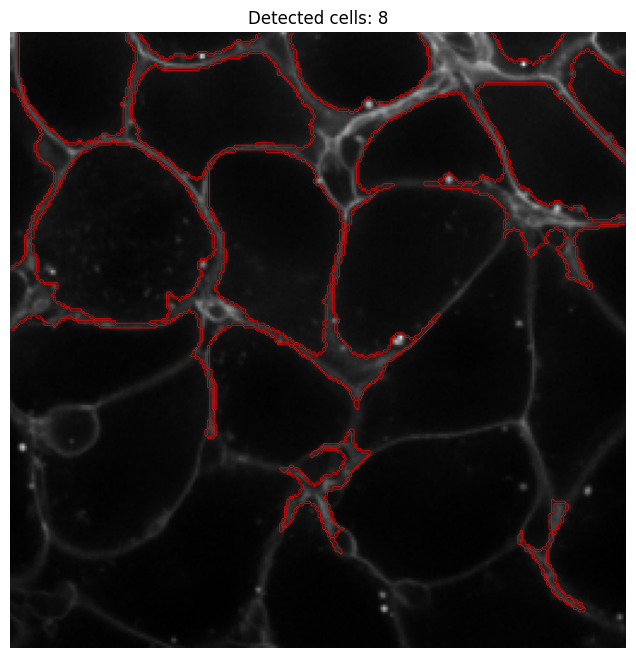

input_host_path: input_data


ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\nTraceback (most recent call last):\n  File "/usr/local/lib/python3.11/site-packages/jupyter_core/utils/__init__.py", line 154, in wrapped\n    asyncio.get_running_loop()\nRuntimeError: no running event loop\n\nDuring handling of the above exception, another exception occurred:\n\nTraceback (most recent call last):\n  File "/usr/local/bin/jupyter-nbconvert", line 8, in <module>\n    sys.exit(main())\n             ^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/jupyter_core/application.py", line 284, in launch_instance\n    super().launch_instance(argv=argv, **kwargs)\n  File "/usr/local/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance\n    app.start()\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 420, in start\n    self.convert_notebooks()\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks\n    self.convert_single_notebook(notebook_filename)\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook\n    output, resources = self.export_single_notebook(\n                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 487, in export_single_notebook\n    output, resources = self.exporter.from_filename(\n                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 201, in from_filename\n    return self.from_file(f, resources=resources, **kw)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 220, in from_file\n    return self.from_notebook_node(\n           ^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/notebook.py", line 36, in from_notebook_node\n    nb_copy, resources = super().from_notebook_node(nb, resources, **kw)\n                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 154, in from_notebook_node\n    nb_copy, resources = self._preprocess(nb_copy, resources)\n                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 353, in _preprocess\n    nbc, resc = preprocessor(nbc, resc)\n                ^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/preprocessors/base.py", line 48, in __call__\n    return self.preprocess(nb, resources)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/preprocessors/execute.py", line 103, in preprocess\n    self.preprocess_cell(cell, resources, index)\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/preprocessors/execute.py", line 124, in preprocess_cell\n    cell = self.execute_cell(cell, index, store_history=True)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/jupyter_core/utils/__init__.py", line 158, in wrapped\n    return loop.run_until_complete(inner)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/asyncio/base_events.py", line 654, in run_until_complete\n    return future.result()\n           ^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbclient/client.py", line 1062, in async_execute_cell\n    await self._check_raise_for_error(cell, cell_index, exec_reply)\n  File "/usr/local/lib/python3.11/site-packages/nbclient/client.py", line 918, in _check_raise_for_error\n    raise CellExecutionError.from_cell_and_msg(cell, exec_reply_content)\nnbclient.exceptions.CellExecutionError: An error occurred while executing the following cell:\

len code (aft): 4860
len code (bef): 4860


# 2. Result

ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 362571 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=20.35037326812744, container_id='0d6ed0f8840f47755363f78185631809f669a38bc4a513ca2f6d05172074aa35', code='"""\nCell segmentation and average area measurement.\n\n- Loads a single‑channel TIF image.\n- Enhances contrast with adaptive histogram equalisation.\n- Segments dark cells (inside bright membranes) using Otsu + distance‑transform + watershed.\n- Filters objects by a sensible area range.\n- Saves the binary mask and labelled image to ``display_output/``.\n- Returns the average cell area (pixels²) and the number of detected cells.\n"""\n\nfrom pathlib import Path\nimport warnings\n\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom skimage import io, filters, morphology, measure, exposure, segmentation, util, feature\nfrom scipy import ndimage as ndi\n\n\ndef segment_cells(img_path: str) -> tuple[float, int]:\n    """Return average cell area (px²) and number of detected cells."""\n    # ------------------------------------------------------------\n    # 1️⃣ Load image\n    # ------------------------------------------------------------\n    try:\n        image = io.imread(img_path)\n    except FileNotFoundError as e:\n        raise RuntimeError(f"Cannot read image: {img_path}") from e\n\n    # Ensure float format in [0, 1]\n    image = util.img_as_float(image)\n\n    # ------------------------------------------------------------\n    # 2️⃣ Pre‑processing – contrast enhancement\n    # ------------------------------------------------------------\n    # Invert (cells become bright) and apply adaptive histogram equalisation\n    inv_image = exposure.rescale_intensity(1.0 - image)\n    inv_image = exposure.equalize_adapthist(inv_image, clip_limit=0.03)\n\n    # Light Gaussian blur to suppress noise\n    blur = filters.gaussian(inv_image, sigma=1.0)\n\n    # ------------------------------------------------------------\n    # 3️⃣ Initial binary mask (global Otsu)\n    # ------------------------------------------------------------\n    thresh_val = filters.threshold_otsu(blur)\n    binary_cells = blur > thresh_val\n\n    # Remove tiny artefacts\n    clean_mask = morphology.remove_small_objects(binary_cells, min_size=100)\n\n    # ------------------------------------------------------------\n    # 4️⃣ Watershed separation\n    # ------------------------------------------------------------\n    # Distance map\n    dist = ndi.distance_transform_edt(clean_mask)\n\n    # Local maxima as markers\n    coords = feature.peak_local_max(\n        dist,\n        footprint=morphology.disk(5),\n        labels=clean_mask,\n    )\n    marker_mask = np.zeros(dist.shape, dtype=bool)\n    marker_mask[tuple(coords.T)] = True\n    markers = measure.label(marker_mask)\n\n    # Watershed\n    label_image = segmentation.watershed(-dist, markers, mask=clean_mask)\n\n    # ------------------------------------------------------------\n    # 5️⃣ Area filtering\n    # ------------------------------------------------------------\n    areas = np.array([prop.area for prop in measure.regionprops(label_image)])\n    # Keep cells within a realistic size range (adjust if needed)\n    areas = areas[(areas >= 500) & (areas <= 5_000)]\n\n    if areas.size == 0:\n        raise RuntimeError("No cells detected after area filtering.")\n\n    average_area = areas.mean()\n    num_cells = areas.size\n\n    # ------------------------------------------------------------\n    # 6️⃣ Sanity check on cell count\n    # ------------------------------------------------------------\n    if not 10 <= num_cells <= 20:\n        warnings.warn(\n            f"Detected {num_cells} cells – outside the expected range (≈15).",\n            UserWarning,\n        )\n\n    # ------------------------------------------------------------\n    # 7️⃣ Save results\n    # --------------------
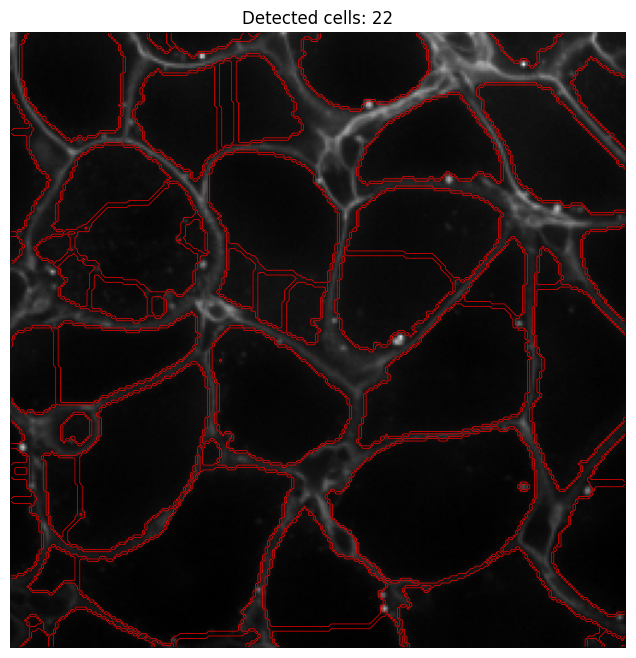

input_host_path: input_data
len code (aft): 5742
len code (bef): 5742


# 3. Result

ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 351584 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=20.173365831375122, container_id='4d4211d36fb194d90183b65a1736d059afb6ba954f5e3e302eb491b91a104634', code='"""\nCell segmentation and average area measurement.\n\n- Loads a single‑channel TIF image.\n- Enhances contrast, denoises and removes thin membrane fragments.\n- Segments dark cells (inside bright membranes) using Otsu + distance‑transform + watershed.\n- Filters objects by a realistic area range.\n- Saves the binary mask and labelled image to ``display_output/``.\n- Returns the average cell area (pixels²) and the number of detected cells.\n"""\n\nfrom pathlib import Path\nimport logging\n\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom skimage import io, filters, morphology, measure, exposure, segmentation, util, feature\nfrom scipy import ndimage as ndi\n\n# ----------------------------------------------------------------------\n# Logging configuration\n# ----------------------------------------------------------------------\nlogger = logging.getLogger(__name__)\nif not logger.handlers:\n    logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")\n\ndef segment_cells(img_path: Path) -> tuple[float, int]:\n    """\n    Segment dark cells (inside bright membranes) from a single‑channel TIF.\n\n    Parameters\n    ----------\n    img_path : Path\n        Path to the image file.\n\n    Returns\n    -------\n    average_area : float\n        Mean cell area in pixel².\n    n_cells : int\n        Number of cells kept after size filtering.\n    """\n    # ------------------------------------------------------------\n    # 1️⃣ Load image\n    # ------------------------------------------------------------\n    try:\n        image = io.imread(img_path)\n    except (FileNotFoundError, IOError) as e:\n        raise RuntimeError(f"Cannot read image: {img_path}") from e\n\n    # Ensure float format in [0, 1]\n    image = util.img_as_float(image)\n\n    # ------------------------------------------------------------\n    # 2️⃣ Pre‑processing – contrast enhancement & denoising\n    # ------------------------------------------------------------\n    # Invert (cells become bright)\n    inv_image = exposure.rescale_intensity(1.0 - image)\n\n    # Adaptive histogram equalisation\n    inv_image = exposure.equalize_adapthist(inv_image, clip_limit=0.03)\n\n    # Median filter to suppress salt‑and‑pepper noise\n    denoised = filters.median(inv_image, morphology.disk(2))\n\n    # Light Gaussian blur (preserve boundaries)\n    blur = filters.gaussian(denoised, sigma=0.8)\n\n    # ------------------------------------------------------------\n    # 3️⃣ Initial binary mask (global Otsu) + morphological opening\n    # ------------------------------------------------------------\n    thresh_val = filters.threshold_otsu(blur)\n    binary = blur > thresh_val\n\n    # Opening to break thin membrane connections\n    opened = morphology.opening(binary, morphology.disk(3))\n\n    # Remove tiny artefacts\n    clean_mask = morphology.remove_small_objects(opened, min_size=150)\n\n    # ------------------------------------------------------------\n    # 4️⃣ Watershed separation\n    # ------------------------------------------------------------\n    # Distance map\n    dist = ndi.distance_transform_edt(clean_mask)\n\n    # Local maxima as markers (dynamic min_distance)\n    coords = feature.peak_local_max(\n        dist,\n        min_distance=10,\n        labels=clean_mask,\n        exclude_border=False,\n    )\n    marker_mask = np.zeros(dist.shape, dtype=bool)\n    marker_mask[tuple(coords.T)] = True\n    markers = measure.label(marker_mask)\n\n    # Watershed\n    label_image = segmentation.watershed(-dist, markers, mask=clean_mask)\n\n    # ------------------------------------------------------------\n    # 5️⃣ Area fil
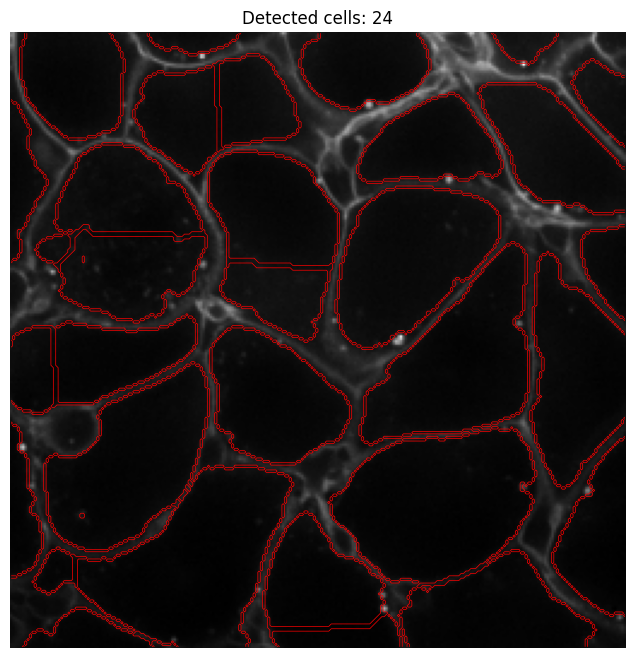

input_host_path: input_data


ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\nTraceback (most recent call last):\n  File "/usr/local/lib/python3.11/site-packages/jupyter_core/utils/__init__.py", line 154, in wrapped\n    asyncio.get_running_loop()\nRuntimeError: no running event loop\n\nDuring handling of the above exception, another exception occurred:\n\nTraceback (most recent call last):\n  File "/usr/local/bin/jupyter-nbconvert", line 8, in <module>\n    sys.exit(main())\n             ^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/jupyter_core/application.py", line 284, in launch_instance\n    super().launch_instance(argv=argv, **kwargs)\n  File "/usr/local/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance\n    app.start()\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 420, in start\n    self.convert_notebooks()\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks\n    self.convert_single_notebook(notebook_filename)\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook\n    output, resources = self.export_single_notebook(\n                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 487, in export_single_notebook\n    output, resources = self.exporter.from_filename(\n                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 201, in from_filename\n    return self.from_file(f, resources=resources, **kw)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 220, in from_file\n    return self.from_notebook_node(\n           ^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/notebook.py", line 36, in from_notebook_node\n    nb_copy, resources = super().from_notebook_node(nb, resources, **kw)\n                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 154, in from_notebook_node\n    nb_copy, resources = self._preprocess(nb_copy, resources)\n                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 353, in _preprocess\n    nbc, resc = preprocessor(nbc, resc)\n                ^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/preprocessors/base.py", line 48, in __call__\n    return self.preprocess(nb, resources)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/preprocessors/execute.py", line 103, in preprocess\n    self.preprocess_cell(cell, resources, index)\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/preprocessors/execute.py", line 124, in preprocess_cell\n    cell = self.execute_cell(cell, index, store_history=True)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/jupyter_core/utils/__init__.py", line 158, in wrapped\n    return loop.run_until_complete(inner)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/asyncio/base_events.py", line 654, in run_until_complete\n    return future.result()\n           ^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbclient/client.py", line 1062, in async_execute_cell\n    await self._check_raise_for_error(cell, cell_index, exec_reply)\n  File "/usr/local/lib/python3.11/site-packages/nbclient/client.py", line 918, in _check_raise_for_error\n    raise CellExecutionError.from_cell_and_msg(cell, exec_reply_content)\nnbclient.exceptions.CellExecutionError: An error occurred while executing the following cell:\

ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\nTraceback (most recent call last):\n  File "/usr/local/lib/python3.11/site-packages/jupyter_core/utils/__init__.py", line 154, in wrapped\n    asyncio.get_running_loop()\nRuntimeError: no running event loop\n\nDuring handling of the above exception, another exception occurred:\n\nTraceback (most recent call last):\n  File "/usr/local/bin/jupyter-nbconvert", line 8, in <module>\n    sys.exit(main())\n             ^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/jupyter_core/application.py", line 284, in launch_instance\n    super().launch_instance(argv=argv, **kwargs)\n  File "/usr/local/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance\n    app.start()\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 420, in start\n    self.convert_notebooks()\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks\n    self.convert_single_notebook(notebook_filename)\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_notebook\n    output, resources = self.export_single_notebook(\n                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/nbconvertapp.py", line 487, in export_single_notebook\n    output, resources = self.exporter.from_filename(\n                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 201, in from_filename\n    return self.from_file(f, resources=resources, **kw)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 220, in from_file\n    return self.from_notebook_node(\n           ^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/notebook.py", line 36, in from_notebook_node\n    nb_copy, resources = super().from_notebook_node(nb, resources, **kw)\n                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 154, in from_notebook_node\n    nb_copy, resources = self._preprocess(nb_copy, resources)\n                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/exporters/exporter.py", line 353, in _preprocess\n    nbc, resc = preprocessor(nbc, resc)\n                ^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/preprocessors/base.py", line 48, in __call__\n    return self.preprocess(nb, resources)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/preprocessors/execute.py", line 103, in preprocess\n    self.preprocess_cell(cell, resources, index)\n  File "/usr/local/lib/python3.11/site-packages/nbconvert/preprocessors/execute.py", line 124, in preprocess_cell\n    cell = self.execute_cell(cell, index, store_history=True)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/jupyter_core/utils/__init__.py", line 158, in wrapped\n    return loop.run_until_complete(inner)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/asyncio/base_events.py", line 654, in run_until_complete\n    return future.result()\n           ^^^^^^^^^^^^^^^\n  File "/usr/local/lib/python3.11/site-packages/nbclient/client.py", line 1062, in async_execute_cell\n    await self._check_raise_for_error(cell, cell_index, exec_reply)\n  File "/usr/local/lib/python3.11/site-packages/nbclient/client.py", line 918, in _check_raise_for_error\n    raise CellExecutionError.from_cell_and_msg(cell, exec_reply_content)\nnbclient.exceptions.CellExecutionError: An error occurred while executing the following cell:\

len code (aft): 6178


ExecutionResult(stdout='[NbConvertApp] Converting notebook notebook.ipynb to notebook\n[NbConvertApp] Writing 230379 bytes to /display_output/notebook_executed.ipynb\n', stderr='', exit_code=0, execution_time=20.795241355895996, container_id='33913b1710f65efe45d370bfc326f96f7850cae25da957ab5b6b9624f7e9bb62', code='"""\nCell segmentation and average area measurement.\n\n- Loads a single‑channel TIF image.\n- Enhances contrast, denoises and removes thin membrane fragments.\n- Segments dark cells (inside bright membranes) using Otsu + distance‑transform + watershed.\n- Filters objects by an adaptive area range.\n- Saves the binary mask, labelled image and average area to ``display_output/``.\n- Prints a description and then the numeric average area (pixel²) as the final result.\n"""\n\nfrom pathlib import Path\nimport logging\n\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport pandas as pd\nfrom skimage import (\n    io,\n    filters,\n    morphology,\n    measure,\n    exposure,\n    segmentation,\n    util,\n    feature,\n)\nfrom scipy import ndimage as ndi\n\n# ----------------------------------------------------------------------\n# Simple logger for notebooks\n# ----------------------------------------------------------------------\nlogger = logging.getLogger(__name__)\nlogger.setLevel(logging.INFO)\nif not logger.handlers:\n    logger.addHandler(logging.StreamHandler())\n\n# ----------------------------------------------------------------------\n# Helper\n# ----------------------------------------------------------------------\ndef _check_input(p: Path) -> None:\n    if not p.is_file():\n        raise FileNotFoundError(f"Image not found: {p}")\n\n# ----------------------------------------------------------------------\ndef segment_cells(img_path: Path) -> tuple[float, int]:\n    """\n    Segment dark cells (inside bright membranes) and compute average area.\n\n    Returns\n    -------\n    average_area : float\n        Mean cell area in pixel². Returns 0.0 if no cells are found.\n    n_cells : int\n        Number of cells after filtering. Returns 0 if no cells are found.\n    """\n    # 1️⃣ Load image\n    _check_input(img_path)\n    image = io.imread(img_path)\n    if image.ndim != 2:\n        raise ValueError("Only 2‑D single‑channel images are supported.")\n    image = util.img_as_float(image)\n\n    # 2️⃣ Pre‑processing\n    inv_image = exposure.rescale_intensity(1.0 - image)               # cells become bright\n    inv_image = exposure.equalize_adapthist(inv_image, clip_limit=0.03)\n    blur = filters.median(inv_image, morphology.disk(3))\n\n    # 3️⃣ Binary mask – keep dark cells after inversion\n    thresh = filters.threshold_otsu(blur)\n    binary = blur < thresh                                            # cells are dark after inversion\n\n    # Optional: suppress thin bright membranes\n    membrane = filters.sobel(blur) > filters.threshold_triangle(\n        filters.sobel(blur)\n    )\n    membrane = morphology.dilation(membrane, morphology.disk(2))\n    binary = binary & ~membrane\n\n    # Clean small artefacts\n    clean_mask = morphology.remove_small_objects(binary, min_size=200)\n\n    # 4️⃣ Watershed separation\n    dist = ndi.distance_transform_edt(clean_mask)\n    local_max = feature.peak_local_max(\n        dist, footprint=morphology.disk(5), labels=clean_mask\n    )\n    marker_mask = np.zeros_like(dist, dtype=bool)\n    if local_max.size > 0:\n        marker_mask[tuple(local_max.T)] = True\n    markers = measure.label(marker_mask)\n    label_image = segmentation.watershed(-dist, markers, mask=clean_mask)\n\n    # 5️⃣ Area filtering (adaptive)\n    areas = np.fromiter(\n        (prop.area for prop in measure.regionprops(label_image)), dtype=int\n    )\n\n    # If no objects were found, return zeros early (skip further processing)\n    if areas.size == 0:\n        logger.warning("No cells detected in the image.")\n        out_dir = Path("display_output")\n        out_dir.mkdir(parents=True, exis
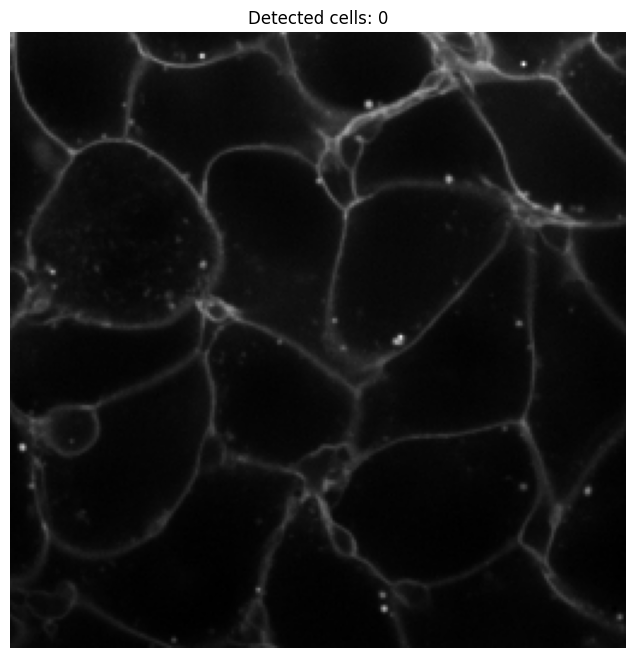

In [2]:
%%bob 
I would like to segment the cells in input_data/image.tif and measure their average area.
Make sure to not segment the membranes. I would like to segment the cells; which are dark between the bright membranes.
Hint: There should be about 15 cells  